<a href="https://colab.research.google.com/github/badaraaliouguindo/chest-xray-pneumonia-detector/blob/main/notebooks/01_EDA_XRay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive, files

# 1. Monte Google Drive
drive.mount('/content/drive')

# 2. Vérifie si le dataset est déjà sur Drive
DRIVE_DATA = '/content/drive/MyDrive/chest_xray'

if os.path.exists(DRIVE_DATA):
    print("Dataset déjà sur Drive ✓")
else:
    print("Téléchargement du dataset...")

    # Upload kaggle.json
    files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.system('cp kaggle.json /root/.kaggle/')
    os.system('chmod 600 /root/.kaggle/kaggle.json')
    os.system('pip install kaggle -q')

    # Téléchargement
    os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q')
    os.system('unzip -q chest-xray-pneumonia.zip')

    # Copie vers Drive (une seule fois)
    os.system('cp -r chest_xray /content/drive/MyDrive/')
    print("Dataset copié sur Drive ✓")

# Chemins définitifs
TRAIN_DIR = f'{DRIVE_DATA}/train'
TEST_DIR  = f'{DRIVE_DATA}/test'
VAL_DIR   = f'{DRIVE_DATA}/val'

print(f"\nTrain NORMAL    : {len(os.listdir(f'{TRAIN_DIR}/NORMAL'))}")
print(f"Train PNEUMONIA : {len(os.listdir(f'{TRAIN_DIR}/PNEUMONIA'))}")

Mounted at /content/drive
Téléchargement du dataset...


Saving kaggle.json to kaggle.json
Dataset copié sur Drive ✓

Train NORMAL    : 1341
Train PNEUMONIA : 3875


# Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Chemins
TRAIN_DIR = 'chest_xray/train'
VAL_DIR   = 'chest_xray/val'
TEST_DIR  = 'chest_xray/test'

print("Librairies chargées !")

Librairies chargées !


# Distribution des classes

In [3]:
# Comptage des images
splits = {'Train': TRAIN_DIR, 'Val': VAL_DIR, 'Test': TEST_DIR}

for split, path in splits.items():
    normal    = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    total     = normal + pneumonia
    print(f"{split:6} — NORMAL: {normal:4d} | PNEUMONIA: {pneumonia:4d} | Total: {total:4d}")

Train  — NORMAL: 1341 | PNEUMONIA: 3875 | Total: 5216
Val    — NORMAL:    8 | PNEUMONIA:    8 | Total:   16
Test   — NORMAL:  234 | PNEUMONIA:  390 | Total:  624


# Visualisation de la distribution

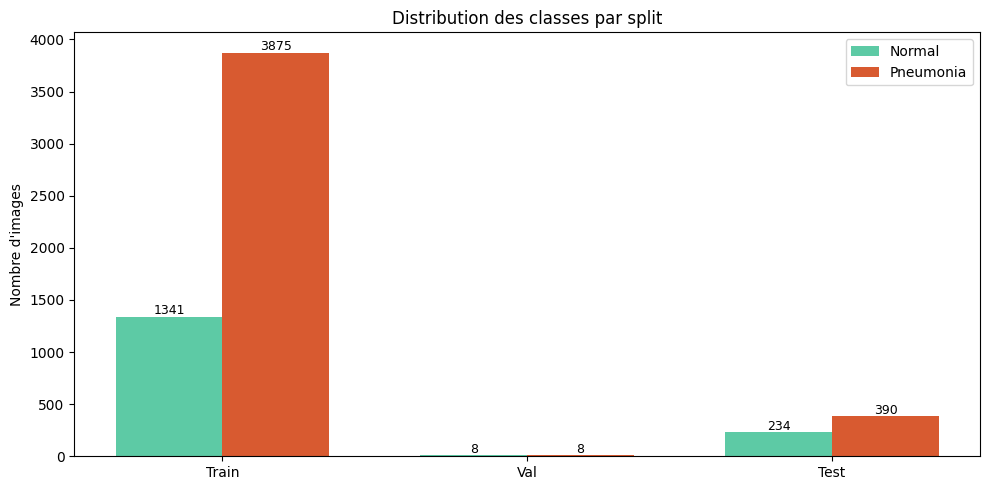

In [4]:
data = {
    'Split':     ['Train', 'Train', 'Val', 'Val', 'Test', 'Test'],
    'Class':     ['Normal', 'Pneumonia'] * 3,
    'Count':     [
        len(os.listdir(f'{TRAIN_DIR}/NORMAL')),
        len(os.listdir(f'{TRAIN_DIR}/PNEUMONIA')),
        len(os.listdir(f'{VAL_DIR}/NORMAL')),
        len(os.listdir(f'{VAL_DIR}/PNEUMONIA')),
        len(os.listdir(f'{TEST_DIR}/NORMAL')),
        len(os.listdir(f'{TEST_DIR}/PNEUMONIA')),
    ]
}

import pandas as pd
df_dist = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.35
splits_list = ['Train', 'Val', 'Test']
normals    = df_dist[df_dist['Class']=='Normal']['Count'].values
pneumonias = df_dist[df_dist['Class']=='Pneumonia']['Count'].values

bars1 = ax.bar(x - w/2, normals,    w, label='Normal',    color='#5DCAA5')
bars2 = ax.bar(x + w/2, pneumonias, w, label='Pneumonia', color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(splits_list)
ax.set_title("Distribution des classes par split")
ax.set_ylabel("Nombre d'images")
ax.legend()

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(int(bar.get_height())), ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(int(bar.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Visualisation des radios

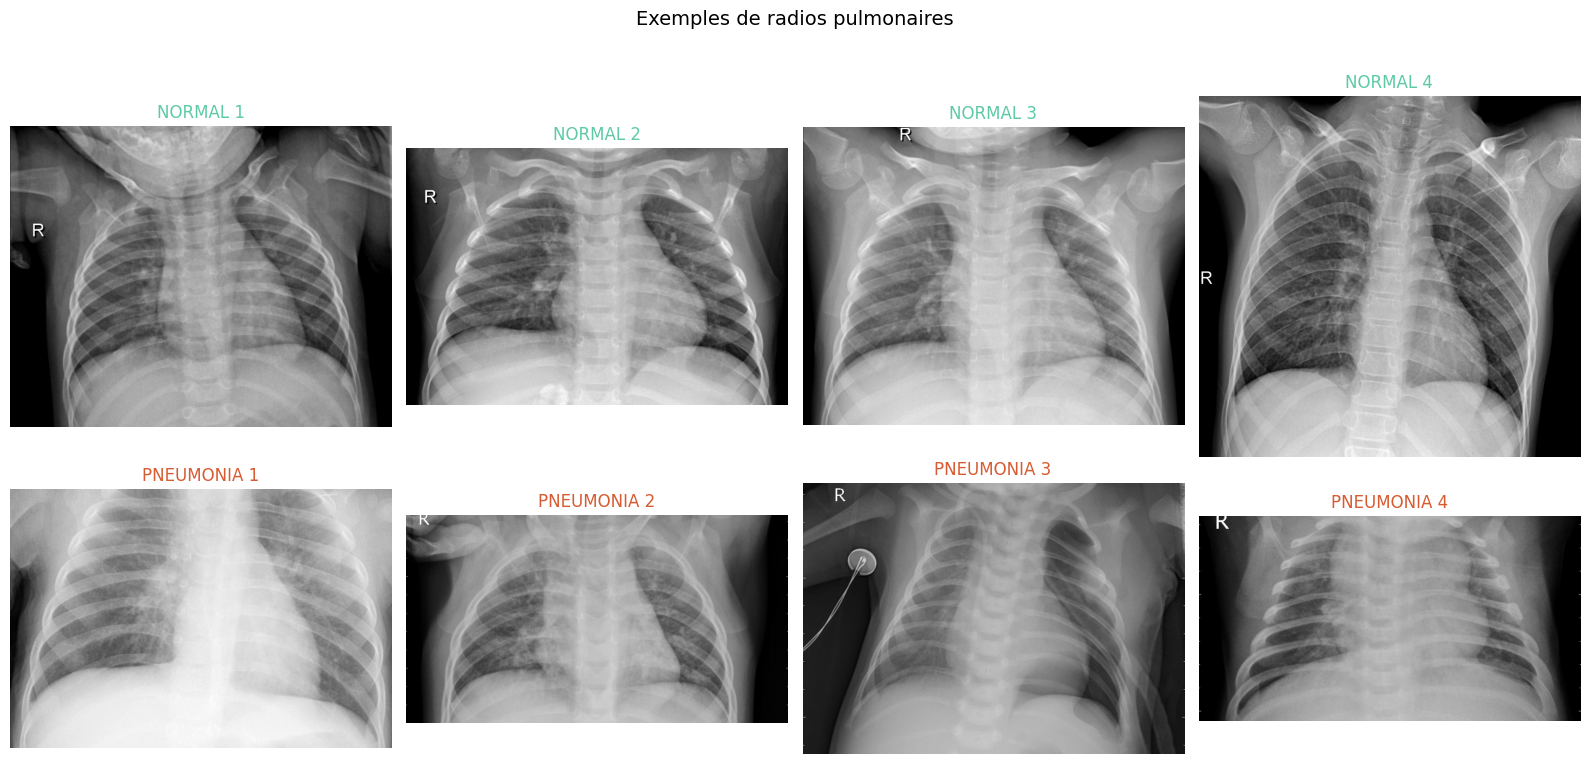

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes[0]):
    img_path = os.path.join(TRAIN_DIR, 'NORMAL',
                os.listdir(f'{TRAIN_DIR}/NORMAL')[i])
    img = Image.open(img_path).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'NORMAL {i+1}', color='#5DCAA5')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    img_path = os.path.join(TRAIN_DIR, 'PNEUMONIA',
                os.listdir(f'{TRAIN_DIR}/PNEUMONIA')[i])
    img = Image.open(img_path).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'PNEUMONIA {i+1}', color='#D85A30')
    ax.axis('off')

plt.suptitle("Exemples de radios pulmonaires", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Analyse des dimensions des images

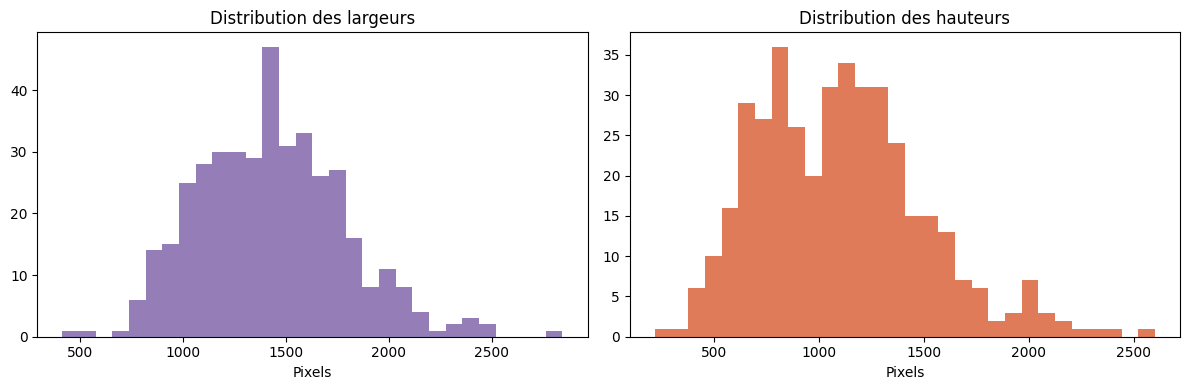

Largeur  — min: 415  max: 2844  moyenne: 1428
Hauteur  — min: 218 max: 2601 moyenne: 1102

On va redimensionner toutes les images à 224x224 pour ResNet50


In [6]:
widths, heights = [], []

for cls in ['NORMAL', 'PNEUMONIA']:
    folder = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(folder)[:200]:
        img = Image.open(os.path.join(folder, fname))
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=30, color='#7B5EA7', alpha=0.8)
axes[0].set_title("Distribution des largeurs")
axes[0].set_xlabel("Pixels")

axes[1].hist(heights, bins=30, color='#D85A30', alpha=0.8)
axes[1].set_title("Distribution des hauteurs")
axes[1].set_xlabel("Pixels")

plt.tight_layout()
plt.show()

print(f"Largeur  — min: {min(widths)}  max: {max(widths)}  moyenne: {int(np.mean(widths))}")
print(f"Hauteur  — min: {min(heights)} max: {max(heights)} moyenne: {int(np.mean(heights))}")
print(f"\nOn va redimensionner toutes les images à 224x224 pour ResNet50")

In [7]:
import os

# 1. Re-téléchargement propre
os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q')
os.system('unzip -q -o chest-xray-pneumonia.zip')

# 2. Vérification locale
base_local = 'chest_xray/train'
for cls in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_local, cls)
    print(f"Local train/{cls} : {len(os.listdir(path))} images")

# 3. Suppression de l'ancienne copie incomplète sur Drive
os.system('rm -rf /content/drive/MyDrive/chest_xray')

# 4. Recopie complète vers Drive
print("\nCopie vers Drive en cours...")
os.system('cp -r chest_xray /content/drive/MyDrive/')
print("Copie terminée ✓")

# 5. Vérification sur Drive
base_drive = '/content/drive/MyDrive/chest_xray/train'
for cls in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_drive, cls)
    print(f"Drive train/{cls} : {len(os.listdir(path))} images")

Local train/NORMAL : 1341 images
Local train/PNEUMONIA : 3875 images

Copie vers Drive en cours...
Copie terminée ✓
Drive train/NORMAL : 1341 images
Drive train/PNEUMONIA : 3875 images
